In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [2]:
raw = np.load("/content/PEMS08.npz")
data = raw["data"].astype(np.float32)

# use traffic flow channel only
data = data[:, :, 0]      # (time, sensors)

SENSORS = data.shape[1]
print("Data shape:", data.shape)


Data shape: (17856, 170)


In [3]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)


In [4]:
SEQ_LEN = 96
PRED_LEN = 12

def create_sequences(data):
    X, Y = [], []
    for i in range(len(data) - SEQ_LEN - PRED_LEN):
        X.append(data[i:i+SEQ_LEN])
        Y.append(data[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])
    return np.array(X), np.array(Y)

X, Y = create_sequences(data)

print("X:", X.shape)
print("Y:", Y.shape)


X: (17748, 96, 170)
Y: (17748, 12, 170)


In [5]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X).float()
        self.Y = torch.tensor(Y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = TrafficDataset(X, Y)


In [6]:
split = int(0.8 * len(dataset))

train_set = torch.utils.data.Subset(dataset, range(split))
val_set   = torch.utils.data.Subset(dataset, range(split, len(dataset)))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32)


In [7]:
class LSTM_LLM_RES(nn.Module):
    def __init__(self, sensors, pred_len):
        super().__init__()

        hidden = 128

        self.input_proj = nn.Linear(sensors, hidden)

        self.lstm = nn.LSTM(
            hidden,
            hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=3
        )

        self.decoder = nn.GRU(
            hidden,
            hidden,
            num_layers=1,
            batch_first=True
        )

        self.output = nn.Linear(hidden, sensors)

        self.pred_len = pred_len

    def forward(self, x):

        x = self.input_proj(x)

        x, _ = self.lstm(x)

        x = self.transformer(x)

        context = x[:, -1:, :]

        outputs = []
        hidden = None
        decoder_input = context

        for _ in range(self.pred_len):

            out, hidden = self.decoder(decoder_input, hidden)
            step = self.output(out)

            outputs.append(step)

            decoder_input = out  # autoregressive

        outputs = torch.cat(outputs, dim=1)

        return outputs


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTM_LLM_RES(SENSORS, PRED_LEN).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=3,
    factor=0.5
)

loss_fn = nn.HuberLoss()


In [10]:
best_val = 1e9
patience = 8
counter = 0

for epoch in range(60):

    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            val_loss += loss_fn(pred, y).item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    print(epoch, train_loss, val_loss)

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


0 0.011717654949238708 0.004345986006785654
1 0.0036022055695915747 0.003355923484746568
2 0.0029525292669171214 0.0028379400431698706
3 0.0025732899942070347 0.0026915843193712936
4 0.002289744563608405 0.0025554168754391504
5 0.002098648113288774 0.002441042709334225
6 0.0019761312056567754 0.0024013130103347
7 0.0018742254246676526 0.0024515679258190364
8 0.0017998438288650668 0.0022927268231518333
9 0.0017319109080032118 0.0022418138598352
10 0.0016816578606701548 0.0023066405944215753
11 0.0016278531968694282 0.002217285135270071
12 0.0015897336041005245 0.002177596052370227
13 0.001554344980799182 0.0021634128766432237
14 0.0015166590128173666 0.002182058610603096
15 0.0014895892813214446 0.0021459441852277597
16 0.0014622903390691052 0.002117950687927471
17 0.0014397299445762827 0.00223254851513408
18 0.0014182315438750895 0.002111467846138571
19 0.0013940237564252908 0.002110975487199654
20 0.0013772052401248868 0.002152393516708954
21 0.0013607803085579763 0.002121672098239598

In [11]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

preds, actual = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        p = model(x).cpu().numpy()
        preds.append(p)
        actual.append(y.numpy())

preds = np.concatenate(preds)
actual = np.concatenate(actual)

preds_denorm = scaler.inverse_transform(
    preds.reshape(-1, preds.shape[-1])
).reshape(preds.shape)

actual_denorm = scaler.inverse_transform(
    actual.reshape(-1, actual.shape[-1])
).reshape(actual.shape)

mae  = np.mean(np.abs(preds_denorm - actual_denorm))
rmse = np.sqrt(np.mean((preds_denorm - actual_denorm)**2))

mask = actual_denorm > 10
mape = np.mean(
    np.abs((actual_denorm[mask] - preds_denorm[mask]) /
           actual_denorm[mask])
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE : 19.841274
RMSE: 31.15984
MAPE: 11.037854


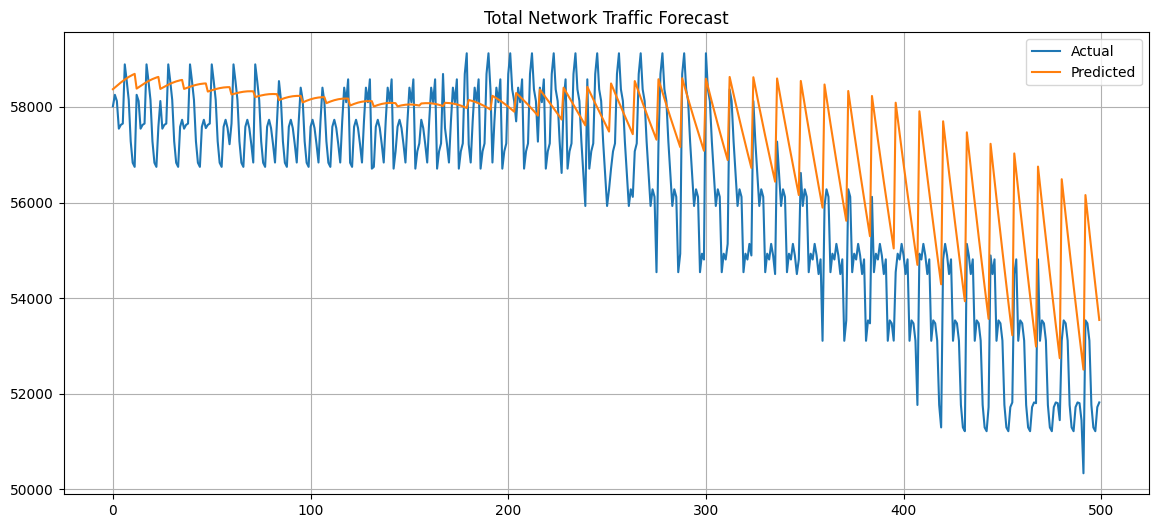

In [12]:
actual_sum = actual_denorm.sum(axis=2)
pred_sum   = preds_denorm.sum(axis=2)

plt.figure(figsize=(14,6))
plt.plot(actual_sum.reshape(-1)[:500], label="Actual")
plt.plot(pred_sum.reshape(-1)[:500], label="Predicted")
plt.title("Total Network Traffic Forecast")
plt.legend()
plt.grid(True)
plt.show()
